Лабораторна робота №2. Архітектура та навчання конволюційних нейронних мереж (Convolutional Neural Networks (CNN))

Завдання.
1. Побудувати конволюційну мережу для розпізнавання рукописних цифр за вказаною технологією.
2. Поміняти алгоритм навчання (оптимізатор) і порівняти результати точності.
3. Поміняти розмірності ядер в конволюційних шарах – спробувати як квадратні так і прямокутні ядра.
4. Додати додаткові шари конволюції і дослідити вплив на точність розпізнавання.
5. Зробити експерименти з різними параметрами аугментації даних.
6. Порівняти точність розробленої мережі в попередньому завданні з точністю розпізнавання LeNet-5 CNN.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix
import itertools
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam, RMSprop,SGD, Adamax, Nadam
from keras.src.callbacks import EarlyStopping
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.callbacks import ReduceLROnPlateau

In [2]:
print(os.listdir("../data/lab2/input"))

['test.csv', 'train.csv']


In [3]:
train = pd.read_csv("../data/lab2/input/train.csv")
print(train.shape)
train.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test = pd.read_csv("../data/lab2/input/test.csv")
print(test.shape)
test.head()

(28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# put labels into y_train variable
Y_train = train["label"]
# Drop 'label' column
X_train = train.drop(labels = ["label"],axis = 1)

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

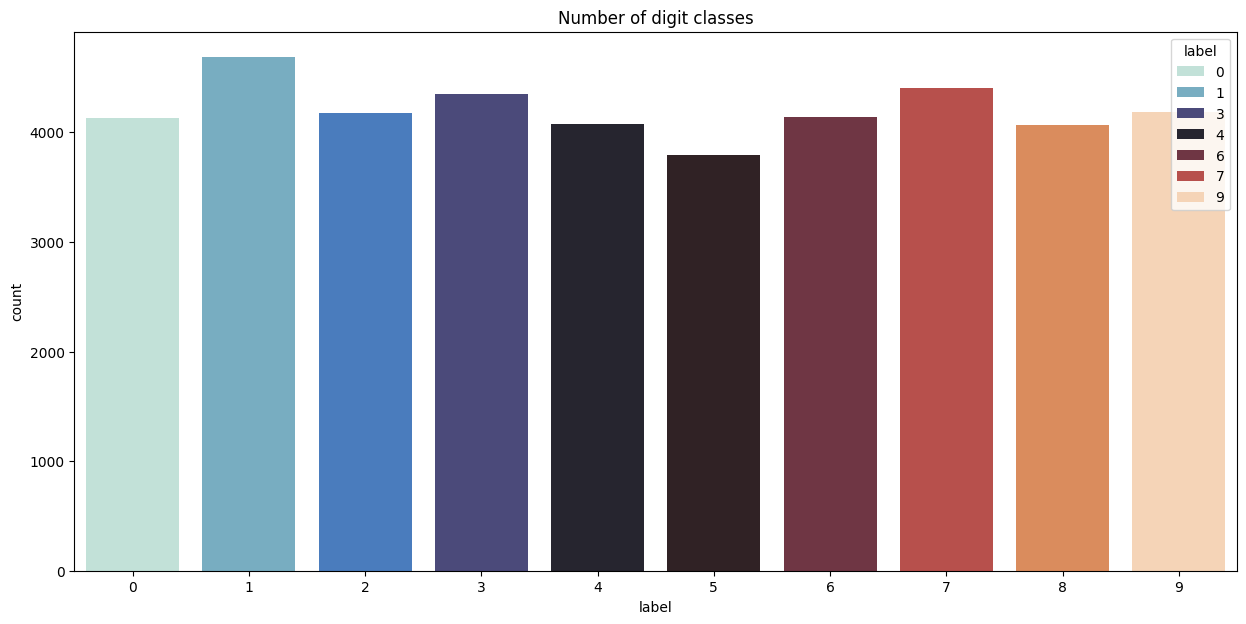

In [6]:
# visualize number of digits classes
plt.figure(figsize=(15,7))
# g = sns.countplot(Y_train, palette="icefire", hue=X_train)
g = sns.countplot(data=train, x='label', palette="icefire", hue="label")
plt.title("Number of digit classes")
Y_train.value_counts()

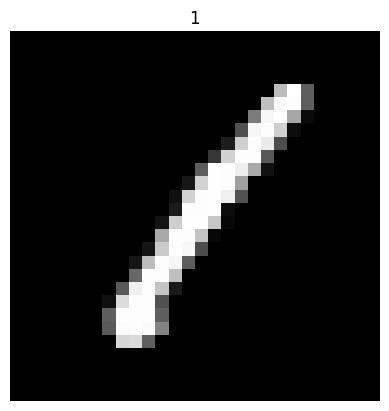

In [7]:
# plot some samples
img = X_train.iloc[0].values
img = img.reshape((28,28))
plt.imshow(img,cmap='gray')
plt.title(train.iloc[0,0])
plt.axis("off")
plt.show()

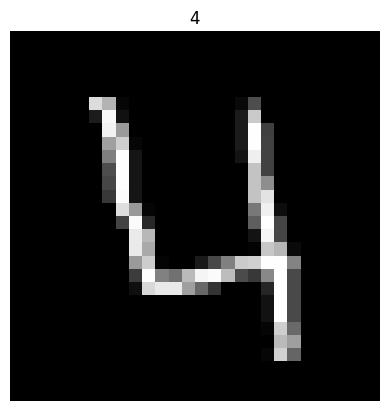

In [8]:
# plot some samples
img = X_train.iloc[3].values
img = img.reshape((28,28))
plt.imshow(img,cmap='gray')
plt.title(train.iloc[3,0])
plt.axis("off")
plt.show()

In [9]:
# Normalize the data
X_train = X_train / 255.0
test = test / 255.0
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 784)
test shape:  (28000, 784)


In [10]:
# Reshape
X_train = X_train.values.reshape(-1,28,28,1)
test = test.values.reshape(-1,28,28,1)
print("x_train shape: ",X_train.shape)
print("test shape: ",test.shape)

x_train shape:  (42000, 28, 28, 1)
test shape:  (28000, 28, 28, 1)


In [11]:
# Label Encoding
# from keras.utils.np_utils import to_categorical # convert to one-hot-encoding
Y_train = to_categorical(Y_train, num_classes = 10)

In [12]:
# Split the train and the validation set for the fitting
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1)
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape (37800, 28, 28, 1)
x_test shape (4200, 28, 28, 1)
y_train shape (37800, 10)
y_test shape (4200, 10)


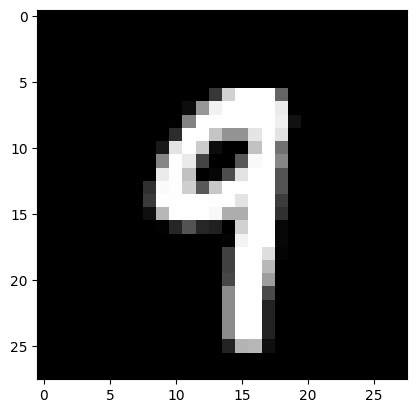

In [13]:
# Some examples
plt.imshow(X_train[2][:,:,0],cmap='gray')
plt.show()

In [29]:
def build_standard_cnn(optimizer=None, kernel1=(5,5), kernel2=(3,3), add_conv=0):

    if optimizer is None:
        optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

    model = Sequential()
    #
    model.add(Input(shape=(28,28,1)))
    model.add(Conv2D(filters = 8, kernel_size = kernel1, padding ='Same', activation ='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    model.add(Dropout(0.25))
    #
    for c in range(add_conv):
        model.add(Conv2D(filters = 16, kernel_size = kernel1, padding ='Same', activation ='relu'))
        model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
        model.add(Dropout(0.25))
    #
    model.add(Conv2D(filters = 16, kernel_size = kernel2, padding ='Same', activation ='relu'))
    model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
    model.add(Dropout(0.25))
    # fully connected
    model.add(Flatten())
    model.add(Dense(256, activation = "relu"))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation = "softmax"))

    # Compile the model
    model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

    return model

In [33]:
def train_cnn(model, epochs=10, batch_size=250, datagen=None):
    # epochs = 20  # for better result increase the epochs
    # batch_size = 250

    # data augmentation
    if datagen is None :
        datagen = ImageDataGenerator(
            featurewise_center=False,  # set input mean to 0 over the dataset
            samplewise_center=False,  # set each sample mean to 0
            featurewise_std_normalization=False,  # divide inputs by std of the dataset
            samplewise_std_normalization=False,  # divide each input by its std
            zca_whitening=False,  # dimension reduction
            rotation_range=0.5,  # randomly rotate images in the range 5 degrees
            zoom_range=0.5,  # Randomly zoom image 5%
            width_shift_range=0.5,  # randomly shift images horizontally 5%
            height_shift_range=0.5,  # randomly shift images vertically 5%
            horizontal_flip=False,  # randomly flip images
            vertical_flip=False)  # randomly flip images

    datagen.fit(X_train)
    # Fit the model
    history = model.fit(
        datagen.flow(X_train, Y_train, batch_size=batch_size),
        epochs=epochs,
        validation_data=(X_val, Y_val),
        steps_per_epoch=np.ceil(X_train.shape[0] / batch_size).astype(int),
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    )

    return history

In [34]:
def plot_loss(history, title):
    # Plot the loss and accuracy curves for training and validation
    plt.plot(history.history['val_loss'], color='b', label="validation_loss")
    plt.title(title)
    plt.xlabel("Number of Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    train_metr = model.evaluate(X_train, Y_train, verbose=0)
    val_metr = model.evaluate(X_val, Y_val, verbose=0)

    print(f"train loss: {train_metr[0]:.4f}, train accuracy: {train_metr[1]:.4f}")
    print(f"validation loss: {val_metr[0]:.4f}, validation accuracy: {val_metr[1]:.4f}")

    # print(f"Validation Loss: {history.history['val_loss'][:1]:.4f}, "
    #       f"Validation Accuracy: {history.history['val_accuracy'][:1]:.4f}")

In [17]:
def plot_confusion_matrix(model, x_val, y_val, title):
    # Predict the values from the validation dataset
    y_pred = model.predict(x_val)
    # Convert predictions classes to one hot vectors
    y_pred_classes = np.argmax(y_pred,axis = 1)
    # Convert validation observations to one hot vectors
    y_true = np.argmax(y_val,axis = 1)
    # compute the confusion matrix
    confusion_mtx = confusion_matrix(y_true, y_pred_classes)
    # plot the confusion matrix
    f,ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(confusion_mtx, annot=True, linewidths=0.01,cmap="Purples",linecolor="gray", fmt= '.1f',ax=ax)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

1. Побудувати конволюційну мережу для розпізнавання рукописних цифр за вказаною технологією.

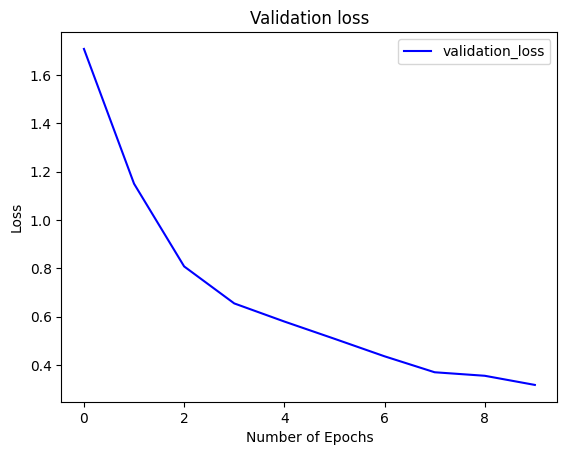

train Loss: 0.2980, train accuracy: 0.9272
validation loss: 0.3172, validation accuracy: 0.9190
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


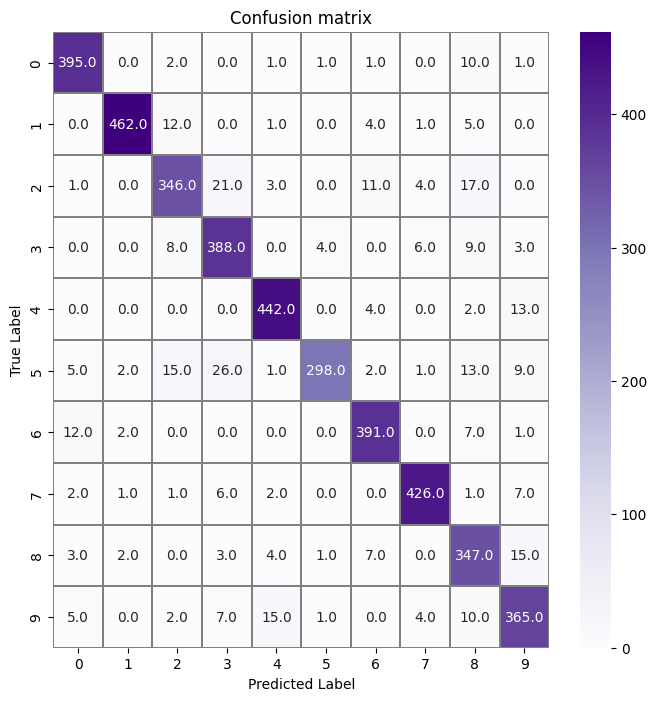

In [18]:
model = build_standard_cnn()
history = train_cnn(model)
plot_loss(history, "Validation loss")
plot_confusion_matrix(model, X_val, Y_val, "Confusion matrix")

2. Поміняти алгоритм навчання (оптимізатор) і порівняти результати точності.

In [41]:
optimizers = {
                'Adam' : Adam(learning_rate=0.001),
                'RMSProp' : RMSprop(learning_rate=0.001),
                'SGD' : SGD(learning_rate=0.001),
                'Adamax' : Adamax(learning_rate=0.001),
                'Nadam' : Nadam(learning_rate=0.001)
            }

Adam optimizer
train Loss: 0.2684, train accuracy: 0.9338
validation loss: 0.2813, validation accuracy: 0.9312
RMSProp optimizer
train Loss: 0.3454, train accuracy: 0.9197
validation loss: 0.3613, validation accuracy: 0.9167
SGD optimizer
train Loss: 2.3011, train accuracy: 0.1470
validation loss: 2.3003, validation accuracy: 0.1452
Adamax optimizer
train Loss: 0.8436, train accuracy: 0.7981
validation loss: 0.8728, validation accuracy: 0.7826
Nadam optimizer
train Loss: 0.2680, train accuracy: 0.9322
validation loss: 0.2832, validation accuracy: 0.9248


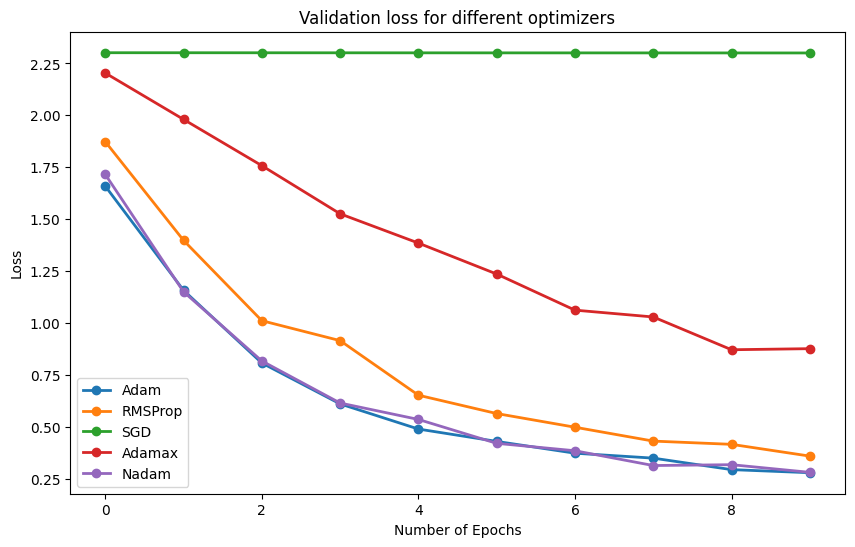

In [42]:
plt.figure(figsize=(10, 6))

for opt_name, opt_obj in optimizers.items():
    model = build_standard_cnn(optimizer=opt_obj)
    history = train_cnn(model)
    plt.plot(history.history['val_loss'], label=opt_name, linewidth=2, marker='o')

    train_metr = model.evaluate(X_train, Y_train, verbose=0)
    val_metr = model.evaluate(X_val, Y_val, verbose=0)

    print(f"\n{opt_name} optimizer")
    print(f"train Loss: {train_metr[0]:.4f}, train accuracy: {train_metr[1]:.4f}")
    print(f"validation loss: {val_metr[0]:.4f}, validation accuracy: {val_metr[1]:.4f}")

plt.title('Validation loss for different optimizers')
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

3. Поміняти розмірності ядер в конволюційних шарах – спробувати як квадратні так і прямокутні ядра.

In [44]:
kernels1 = [2, 3, 5, 7, 9]
kernels2 = [2, 3, 5, 7, 9]


kernel ((2, 2))
train Loss: 0.5786, train accuracy: 0.8684
validation loss: 0.5917, validation accuracy: 0.8650

kernel ((2, 3))
train Loss: 0.4232, train accuracy: 0.9005
validation loss: 0.4349, validation accuracy: 0.9002

kernel ((2, 5))
train Loss: 0.3486, train accuracy: 0.9079
validation loss: 0.3691, validation accuracy: 0.9040

kernel ((2, 7))
train Loss: 0.3787, train accuracy: 0.9034
validation loss: 0.3980, validation accuracy: 0.8976

kernel ((2, 9))
train Loss: 0.2900, train accuracy: 0.9199
validation loss: 0.3085, validation accuracy: 0.9183

kernel ((3, 2))
train Loss: 0.4874, train accuracy: 0.8648
validation loss: 0.5135, validation accuracy: 0.8521

kernel ((3, 3))
train Loss: 0.3093, train accuracy: 0.9159
validation loss: 0.3242, validation accuracy: 0.9119

kernel ((3, 5))
train Loss: 0.2652, train accuracy: 0.9256
validation loss: 0.2810, validation accuracy: 0.9257

kernel ((3, 7))
train Loss: 0.2101, train accuracy: 0.9386
validation loss: 0.2274, validation 

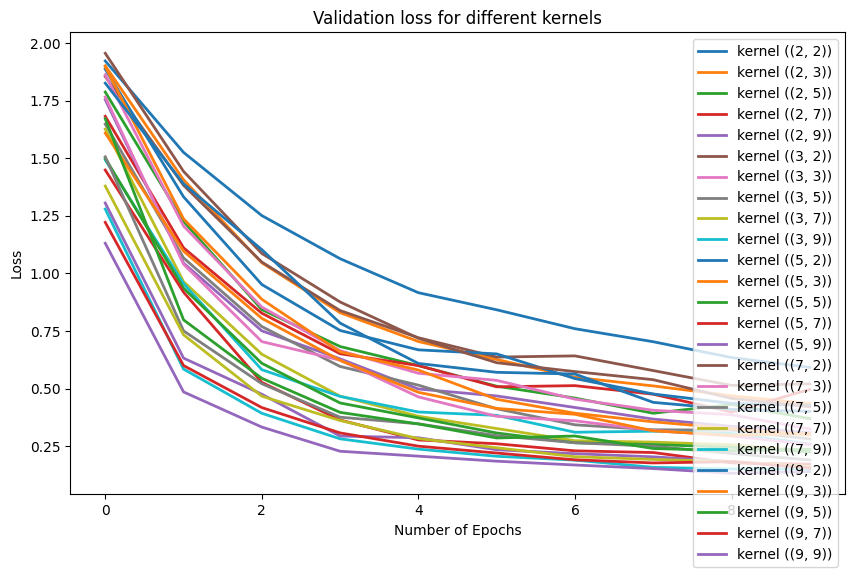

In [45]:
plt.figure(figsize=(10, 6))

for k1 in kernels1:
    for k2 in kernels2:
        model = build_standard_cnn(kernel1=(k1, k2) , kernel2=(k1, k2))
        history = train_cnn(model)
        # plot_loss(history, f"Validation loss (kernel ({k1, k2}))")
        # plot_confusion_matrix(model, X_val, Y_val, f"Confusion matrix ((kernel ({k1, k2}))")
        plt.plot(history.history['val_loss'], label=f"kernel ({k1, k2})", linewidth=2)

        train_metr = model.evaluate(X_train, Y_train, verbose=0)
        val_metr = model.evaluate(X_val, Y_val, verbose=0)

        print(f"\nkernel ({k1, k2})")
        print(f"train Loss: {train_metr[0]:.4f}, train accuracy: {train_metr[1]:.4f}")
        print(f"validation loss: {val_metr[0]:.4f}, validation accuracy: {val_metr[1]:.4f}")

plt.title('Validation loss for different kernels')
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

4. Додати додаткові шари конволюції і дослідити вплив на точність розпізнавання.


1 additional convs
train Loss: 0.2672, train accuracy: 0.9308
validation loss: 0.2876, validation accuracy: 0.9248

2 additional convs
train Loss: 0.4734, train accuracy: 0.8755
validation loss: 0.4797, validation accuracy: 0.8726


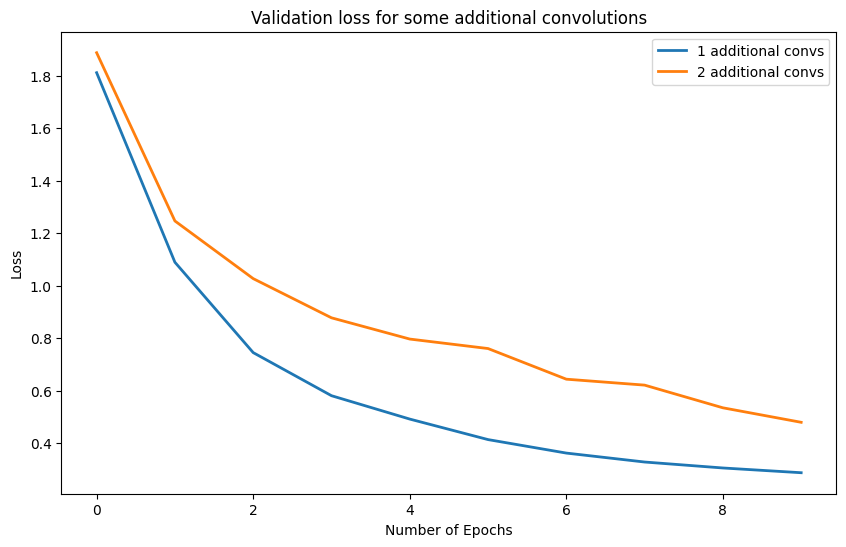

In [50]:
plt.figure(figsize=(10, 6))

for i in range(1, 3):
    model = build_standard_cnn(add_conv=i)
    history = train_cnn(model)
    # plot_loss(history, f"Validation loss ({i} additional convs)")
    # plot_confusion_matrix(model, X_val, Y_val, f"Confusion matrix ({i} additional convs)")
    plt.plot(history.history['val_loss'], label=f"{i} additional convs", linewidth=2)

    train_metr = model.evaluate(X_train, Y_train, verbose=0)
    val_metr = model.evaluate(X_val, Y_val, verbose=0)

    print(f"\n{i} additional convs")
    print(f"train Loss: {train_metr[0]:.4f}, train accuracy: {train_metr[1]:.4f}")
    print(f"validation loss: {val_metr[0]:.4f}, validation accuracy: {val_metr[1]:.4f}")

plt.title('Validation loss for some additional convolutions')
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

5. Зробити експерименти з різними параметрами аугментації даних.

In [39]:
# # data augmentation
datagens = []
datagen1 = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # dimension reduction
    rotation_range=1,  # randomly rotate images in the range 10 degrees
    zoom_range=0.5,  # Randomly zoom image 5%
    width_shift_range=0.5,  # randomly shift images horizontally 5%
    height_shift_range=0.5,  # randomly shift images vertically 5%
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

datagens.append(datagen1)

datagen2 = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # dimension reduction
    rotation_range=0.5,  # randomly rotate images in the range 5 degrees
    zoom_range=1,  # Randomly zoom image 10%
    width_shift_range=0.5,  # randomly shift images horizontally 5%
    height_shift_range=0.5,  # randomly shift images vertically 5%
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

datagens.append(datagen2)

datagen3 = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # dimension reduction
    rotation_range=0.5,  # randomly rotate images in the range 5 degrees
    zoom_range=0.5,  # Randomly zoom image 5%
    width_shift_range=0.5,  # randomly shift images horizontally 5%
    height_shift_range=0.5,  # randomly shift images vertically 5%
    horizontal_flip=True,  # randomly flip images
    vertical_flip=False)  # randomly flip images

datagens.append(datagen3)



datagen1
train Loss: 0.2752, train accuracy: 0.9301
validation loss: 0.2895, validation accuracy: 0.9255

datagen2
train Loss: 0.6365, train accuracy: 0.8106
validation loss: 0.6629, validation accuracy: 0.7962

datagen3
train Loss: 0.6254, train accuracy: 0.8051
validation loss: 0.6403, validation accuracy: 0.8040


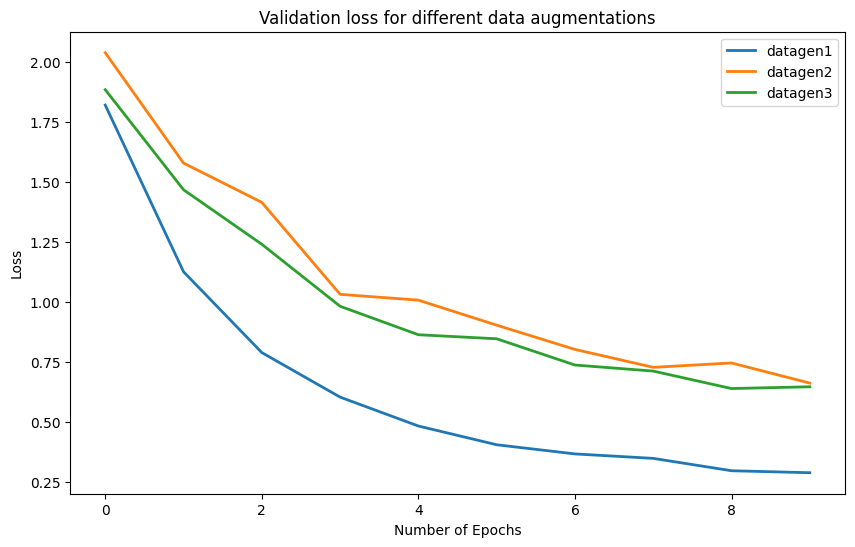

In [43]:
plt.figure(figsize=(10, 6))
for i, dg in enumerate(datagens):
    model = build_standard_cnn()
    history = train_cnn(model, datagen=dg)
    # plot_loss(history, f"Validation loss (datagen{i+1})")
    # plot_confusion_matrix(model, X_val, Y_val, f"Confusion matrix (datagen{i+1})")

    plt.plot(history.history['val_loss'], label=f"datagen{i+1}", linewidth=2)

    train_metr = model.evaluate(X_train, Y_train, verbose=0)
    val_metr = model.evaluate(X_val, Y_val, verbose=0)

    print(f"\ndatagen{i+1}")
    print(f"train Loss: {train_metr[0]:.4f}, train accuracy: {train_metr[1]:.4f}")
    print(f"validation loss: {val_metr[0]:.4f}, validation accuracy: {val_metr[1]:.4f}")

plt.title('Validation loss for different data augmentations')
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

6. Порівняти точність розробленої мережі в попередньому завданні з точністю розпізнавання LeNet-5 CNN.

In [51]:
# LeNet-5 CNN
model = Sequential()

model.add(Input(shape=(28,28,1)))
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu'))
model.add(MaxPool2D(strides=2))

model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPool2D(strides=2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.build()
model.summary()

adam = Adam(learning_rate=5e-4)
model.compile(loss='categorical_crossentropy',
              metrics=['accuracy'],
              optimizer=adam)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    factor=0.2,
    min_lr=1e-6)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1)
datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=100),
    steps_per_epoch=len(X_train)//100,
    epochs=30,
    validation_data=(X_val, Y_val),
    callbacks=[reduce_lr])

val_loss, val_acc = model.evaluate(X_val, Y_val, batch_size=32)
print(f"Validation Accuracy: {val_acc:.4f}")


Model: "sequential_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_185 (Conv2D)             │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_185               │ (None, 14, 14, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_186 (Conv2D)             │ (None, 10, 10, 48)     │        38,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_186               │ (None, 5, 5, 48)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_85 (Flatten)            │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 256)            │       307,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 84)             │        21,588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,174 (1.41 MB)

 Trainable params: 369,174 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8412 - loss: 0.5015 - val_accuracy: 0.9676 - val_loss: 0.1111 - learning_rate: 5.0000e-04
Epoch 2/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9546 - loss: 0.1480 - val_accuracy: 0.9788 - val_loss: 0.0701 - learning_rate: 5.0000e-04
Epoch 3/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9683 - loss: 0.1034 - val_accuracy: 0.9848 - val_loss: 0.0499 - learning_rate: 5.0000e-04
Epoch 4/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9747 - loss: 0.0809 - val_accuracy: 0.9857 - val_loss: 0.0477 - learning_rate: 5.0000e-04
Epoch 5/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9778 - loss: 0.0714 - val_accuracy: 0.9886 - val_loss: 0.0407 - learning_rate: 5.0000e-04
Epoch 6/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9817 - loss: 0.0595 - val_accuracy: 0.9860 - val_loss: 0.0468 - learning_rate: 5.0000e-04
Epoch 7/30
378/378 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/ste